# Знакомство с NumPy

Язык программирования Python стал популярен в научной среде и, в частности, в области машинного обучения из-за огромного количества качественных библиотек для работы с разнообразными данными. Две важные библиотеки, с которыми необходимо познакомиться до того, как переходить непосредственно к алгоритмам машинного обучения - это NumPy (https://numpy.org/) и Pandas (https://pandas.pydata.org/), которые составляют основу стека для работы с данными в Python.

В этом семинаре я буду пользоваться иллюстрациями из прекрасной вводной статьи по NumPy (рекомендую к просмотру для закрепления):

*   http://jalammar.github.io/visual-numpy/

![NumPy logo](https://upload.wikimedia.org/wikipedia/commons/1/1a/NumPy_logo.svg)

Математическая основа большинства алгоритмов машинного обучения - это раздел математики, называющийся "линейная алгебра": операции над матрицами, векторами и т.д. В стандартной библиотеке Python нет эффективной реализации математического объекта вектора или матрицы. Если реализовывать их с помощью доступных в Python списков или объектов `array.array`, то из-за общей низкой производительность Python расчёты будут занимать слишком много времени, а доступные ресурсы не будут эффективно утилизироваться. NumPy (Numeric Python) - библиотека, предоставляющая эффективную реализацию объектов векторов, матриц и операций с ними, а засчет того, что ее ядро написано на C и Fortran и очень сильно оптимизировано, достигается впечатляющая вычислительная производительность. Таким образом Python выступает просто как "клей", связывающий вместе низкоуровневый код на C/C++.

Для начала, импортируем NumPy. Сокращение `np` для пакета общеупотребимое и используется везде, включая официальную документацию:

In [1]:
import numpy as np

Основной объект, предоставляемый библиотекой `numpy` - это объект массива `np.array`


![numpy array visualization](http://jalammar.github.io/images/numpy/numpy-array.png)

### Создание одномерных объектов `np.array` (векторов)

Перед началом работы с вектором, его, конечно же, нужно создать. Сделать это можно, например, следующими способами (но не только ими):

1.   Передать список (или другой итерируемый объект)
2.   Создать массив нужного размера, заполненный константой (единицами, нулями и т.д.)
3.   Создать массив нужного размера, заполненный случайными значениями
4.   Больше способов [тут](https://docs.scipy.org/doc/numpy/user/basics.creation.html#arrays-creation) и [тут](https://docs.scipy.org/doc/numpy/reference/routines.array-creation.html#routines-array-creation)




![create numpy array 1](http://jalammar.github.io/images/numpy/create-numpy-array-1.png)

![create numpy array ones, zeros, random](http://jalammar.github.io/images/numpy/create-numpy-array-ones-zeros-random.png)

### Арифметические действия

Над массивами можно проводить арифметические действия, при этом для обычных арифметических операторов (сложение, умножение, вычитание, деление) операции будут производиться **поэлементно**:

![numpy arrays example 1](http://jalammar.github.io/images/numpy/numpy-arrays-example-1.png)

![numpy arrays adding 1](http://jalammar.github.io/images/numpy/numpy-arrays-adding-1.png)

![numpy array substract multiply divide](http://jalammar.github.io/images/numpy/numpy-array-subtract-multiply-divide.png)

В случае арифметической операции с массивом и числом, `numpy` совершит **трансляцию (broadcasting)**:

![numpy array broadcast](http://jalammar.github.io/images/numpy/numpy-array-broadcast.png)

В случае несовпадающих размерностей, мы ожидаемо получим исключение:

In [2]:
arr1, arr2 = np.ones(5), np.ones(3)
arr1 + arr2

ValueError: operands could not be broadcast together with shapes (5,) (3,) 

In [3]:
arr1 = np.ones(3)
arr2 = np.ones(6)
arr1 + arr2

ValueError: operands could not be broadcast together with shapes (3,) (6,) 

### Индексирование

В `numpy` реализована мощная система индексирования, позволяющая обращаться к отдельным элементам массива и т.п. Также, работают срезы по аналогии со списками.

![numpy array slice](http://jalammar.github.io/images/numpy/numpy-array-slice.png)

### Агрегации

Агрегации - это функции, принимающие на вход массив и возвращающие одно число, например поиск максимума, минимума, суммы, среднего, и т.п.

![link numpy array aggregation](http://jalammar.github.io/images/numpy/numpy-array-aggregation.png)

*Задание: создайте с помощью numpy вектор из 179 случайных значений и посчитайте его среднее арифметическое. Проверьте, что значение, полученное с помощью numpy совпадает с plain python*

In [ ]:
# PUT YOUR CODE HERE


### Многомерные массивы (матрицы)

Удобство `numpy` распространяется и на случаи массивов большей размерности.

![numpy array create 2d](http://jalammar.github.io/images/numpy/numpy-array-create-2d.png)

Если арифметические операции производятся над матрицами одного размера, они так же будут выполнены **поэлементно**:

![numpy matrix arithmetic](http://jalammar.github.io/images/numpy/numpy-matrix-arithmetic.png)

Арифметические действия между матрицами разного размера можно проводить, если несовпадающая размерность матрицы равна 1, в таком случае `numpy` опять сделает **broadcasting** и выполнит операцию:

![numpy matrix broadcast](http://jalammar.github.io/images/numpy/numpy-matrix-broadcast.png)

В случае несовпадения размерностей матриц, получим ожидаемое исключение

In [4]:
m1, m2 = np.ones((3, 3)), np.ones((2, 2))
m1 + m2

ValueError: operands could not be broadcast together with shapes (3,3) (2,2) 

Узнать размерность любого объекта `np.array` можно с помощью атрибута `.shape`:

In [5]:
m1.shape, m2.shape

((3, 3), (2, 2))

In [6]:
m1

array([[1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.]])

### Матричное умножение

Матричное умножение можно вызвать с помощью оператора `@` или метода `.dot`:

In [7]:
A = np.array([[1, 2], [3, 4]])
B = np.array([[0, 1], [1, 0]])
A @ B

array([[2, 1],
       [4, 3]])

In [8]:
data = np.array([[1, 2, 3]])
powers_of_ten = np.array([[1, 10], [100, 1000], [10000, 100000]])
data @ powers_of_ten

array([[ 30201, 302010]])

In [9]:
data.dot(powers_of_ten)

array([[ 30201, 302010]])

![numpy matrix dot product 1](http://jalammar.github.io/images/numpy/numpy-matrix-dot-product-1.png)

![numpy matrix dot product 2](http://jalammar.github.io/images/numpy/numpy-matrix-dot-product-2.png)

В случае массивов, матричное произведение превращается в скалярное произведение векторов:

In [10]:
v1, v2 = np.ones(5), np.arange(5)
v1, v2

(array([1., 1., 1., 1., 1.]), array([0, 1, 2, 3, 4]))

In [11]:
v1 @ v2, v1.dot(v2)

(10.0, 10.0)

### Индексирование в матрицах

![numpy matrix indexing](http://jalammar.github.io/images/numpy/numpy-matrix-indexing.png)

### Агрегации в матрицах

![numpy matrix aggregation 1](http://jalammar.github.io/images/numpy/numpy-matrix-aggregation-1.png)

![numpy matrix aggregation 4](http://jalammar.github.io/images/numpy/numpy-matrix-aggregation-4.png)

*Задание: создайте матрицу со случайными значениями (размерность выберите сами).*

1. *Найдите максимальное и минимальное значения в матрице*
2. *Теперь вычтите из всех значений матрицы минимальное, а результат разделите на разницу между максимальным и минимальным*
3. *Теперь в получившейся матрице заново найдите минимальное и максимальное значения*

In [ ]:
# PUT YOUR CODE HERE


### Транспонирование и изменение формы

Транспонирование - операция замены строк на столбцы:

![numpy transpose](http://jalammar.github.io/images/numpy/numpy-transpose.png)

![numpy reshape](http://jalammar.github.io/images/numpy/numpy-reshape.png)

In [12]:
data.reshape(3, -1)

array([[1],
       [2],
       [3]])

### Б**о**льшие размерности



![numpy 3d array](http://jalammar.github.io/images/numpy/numpy-3d-array.png)

![numpy 3d array creation](http://jalammar.github.io/images/numpy/numpy-3d-array-creation.png)

### Практический пример - формула среднеквадратичной ошибки

In [13]:
y_pred = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 13, 15, 11, 10, 9, 12, 4, 2, 0]
y = [1.1, 1.2, 3, 3, 3, 9, 5, 10, 3, 10, 10, 2.3, 4.4, 2, 2, 9, 12, 2, 0, 0]

![mean square error formula](http://jalammar.github.io/images/numpy/mean-square-error-formula.png)

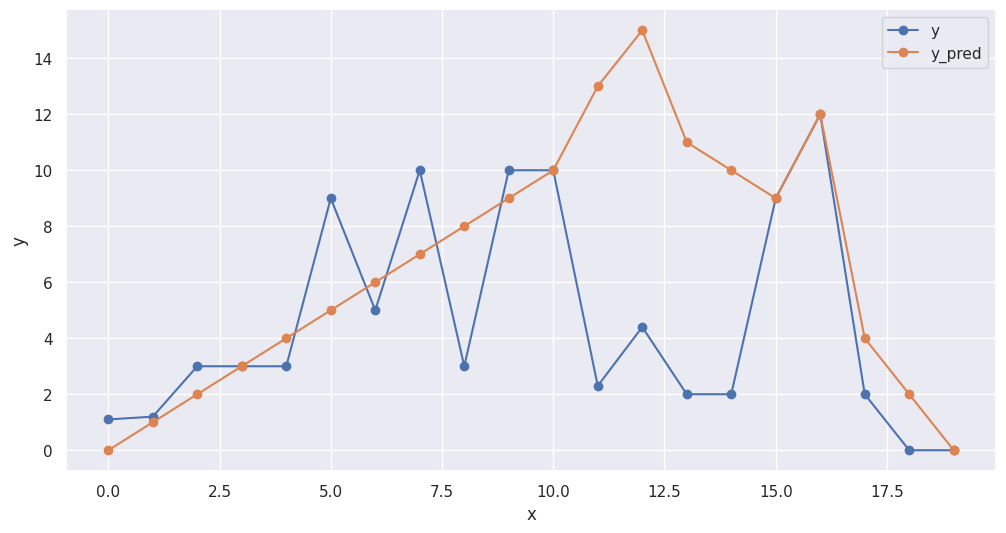

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()


fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(y, label="y", marker="o")
ax.plot(y_pred, label="y_pred", marker="o")
ax.legend()
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.show()

In [15]:
# считаем с помощью Python
mse_python = 0.0
n = len(y)
for i in range(n):
    mse_python += (y_pred[i] - y[i])**2
mse_python /= n
print(f"MSE = {mse_python}")

MSE = 21.755


In [16]:
# считаем с помощью NumPy
y = np.array(y)
y_pred = np.array(y_pred)
mse_np = ((y_pred - y) ** 2).mean()
print(f"MSE = {mse_np}")

MSE = 21.755000000000003


### Бенчмарк NumPy vs. Python

In [17]:
import numpy.typing as npt


def mse_python(y_true: list[float], y_pred: list[float]) -> float:
    n = len(y_true)
    mse = sum((y_true_i - y_pred_i) ** 2 for y_true_i, y_pred_i in zip(y_true, y_pred))
    return mse / n


def mse_numpy(y_true: npt.NDArray[np.float64], y_pred: npt.NDArray[np.float64]) -> float:
    return np.power(y_true - y_pred, 2).mean()

In [18]:
from time import perf_counter


def get_timings(arr_sizes: list[int]) -> dict[str, list[float]]:
    timings = {"python": [], "numpy": []}
    for size in arr_sizes:
        # генерируем пару случайных массивов нужного размера (это время не учитывается)
        y1 = np.random.random(size)
        y2 = np.random.random(size)

        # вычисляем MSE при помощи NumPy
        numpy_start = perf_counter()
        mse = mse_numpy(y1, y2)
        numpy_end = perf_counter()

        # превращаем массивы в списки python (это время не учитывается)
        y1 = y1.tolist()
        y2 = y2.tolist()

        # вычисляем MSE с помощью python
        python_start = perf_counter()
        mse = mse_python(y1, y2)
        python_end = perf_counter()

        timings["numpy"].append(numpy_end - numpy_start)
        timings["python"].append(python_end - python_start)
    return timings

In [19]:
arr_sizes = [2**i for i in range(10, 24)]
timings = get_timings(arr_sizes)

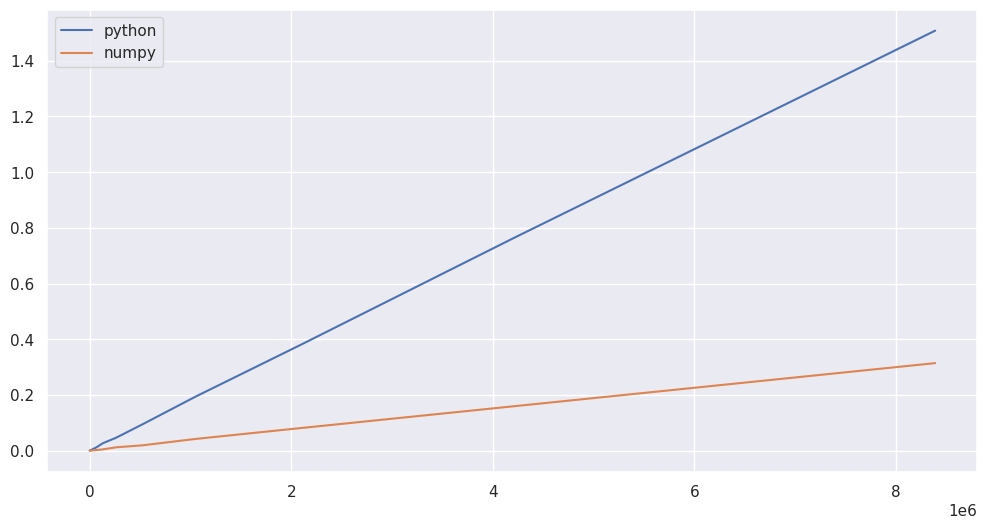

In [21]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(arr_sizes, timings["python"], label="python")
ax.plot(arr_sizes, timings["numpy"], label="numpy")
ax.legend()
plt.show()